Current Working Directory:
C:\Users\Yousuf Traders

Dataset Loaded Successfully!

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Missi

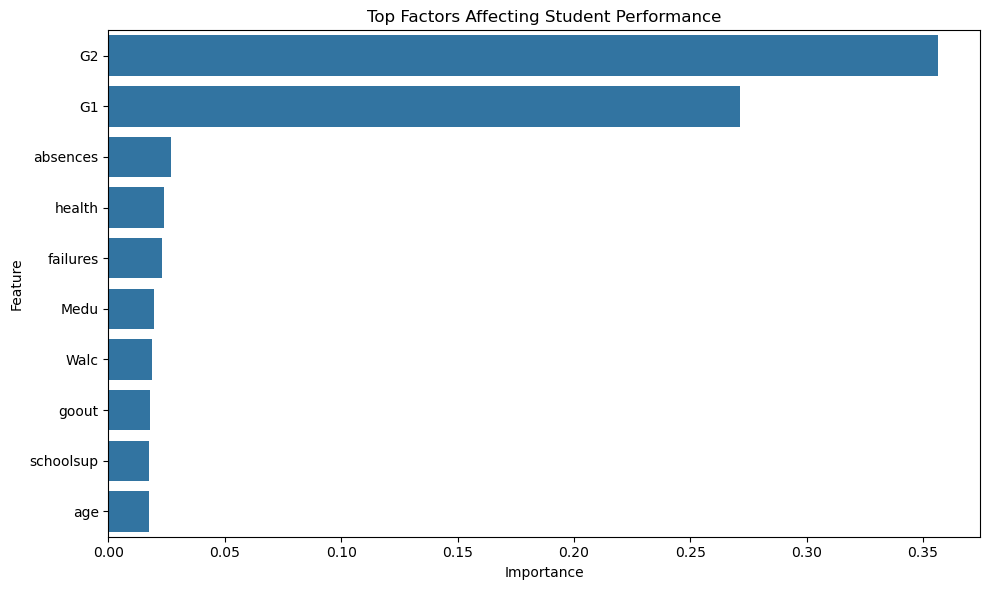

In [1]:
#STUDENT PERFORMANCE PREDECTION

1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import os

# 2. CHECK CURRENT DIRECTORY

print("Current Working Directory:")
print(os.getcwd())

# 3. LOAD DATASET
# IMPORTANT: Keep CSV in same folder OR use full path

df = pd.read_csv("C:/Users/Yousuf Traders/Downloads/student-mat.csv", sep=';')

print("\nDataset Loaded Successfully!\n")
print(df.head())

# 4. CHECK MISSING VALUES

print("\nMissing Values:\n")
print(df.isnull().sum())

# 5. HANDLE MISSING VALUES

imputer = SimpleImputer(strategy='most_frequent')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 6. ENCODE CATEGORICAL DATA

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 7. CREATE TARGET VARIABLE

# Pass = 1 (>=10), Fail = 0 (<10)
df['result'] = df['G3'].apply(lambda x: 1 if int(x) >= 10 else 0)

# 8. DEFINE FEATURES & TARGET

X = df.drop(['G3', 'result'], axis=1)
y = df['result']

# 9. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 10. FEATURE SCALING

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 11. LOGISTIC REGRESSION

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

# 12. RANDOM FOREST

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

# 13. CLASSIFICATION REPORT

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# 14. FEATURE IMPORTANCE

importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:\n")
print(importance_df.head(10))


# 15. VISUALIZATION

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top Factors Affecting Student Performance")
plt.tight_layout()
plt.show()